## **Hyperparameter Tuning**

In [1]:
import pandas as pd

df = pd.read_csv('data/final_clustered_data.csv')

In [2]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
'person_home_ownership',
'loan_intent',
'loan_grade',
'cb_person_default_on_file',
'age_group',
'income_group'
]

for col in cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(y_train.shape)

(40523, 16)
(40523,)


## **Probability Prediction**

In [5]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1]
}
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [6]:
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

In [7]:
best_model = grid.best_estimator_

In [8]:
probability = best_model.predict_proba(X_test)

In [9]:
default_probability = probability[:,1]

## **Risk Scoring System**

In [10]:
def risk_category(prob):

    if prob <= 0.2:
        return 'Low Risk'

    elif prob <= 0.5:
        return 'Medium Risk'

    else:
        return 'High Risk'

In [11]:
risk = [risk_category(i)
        for i in default_probability]

## **Create Prediction DataFrame**

In [12]:
prediction_df = pd.DataFrame({

'Actual':y_test,

'Probability':default_probability,

'Risk_Level':risk

})

In [13]:
prediction_df.head()

,Actual,Probability,Risk_Level
43929,1,0.987554,High Risk
6651,0,0.101133,Low Risk
25055,1,0.999292,High Risk
22707,0,0.001857,Low Risk
20807,0,0.395709,Medium Risk


## **SHAP Explainable AI**

In [14]:
import shap
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

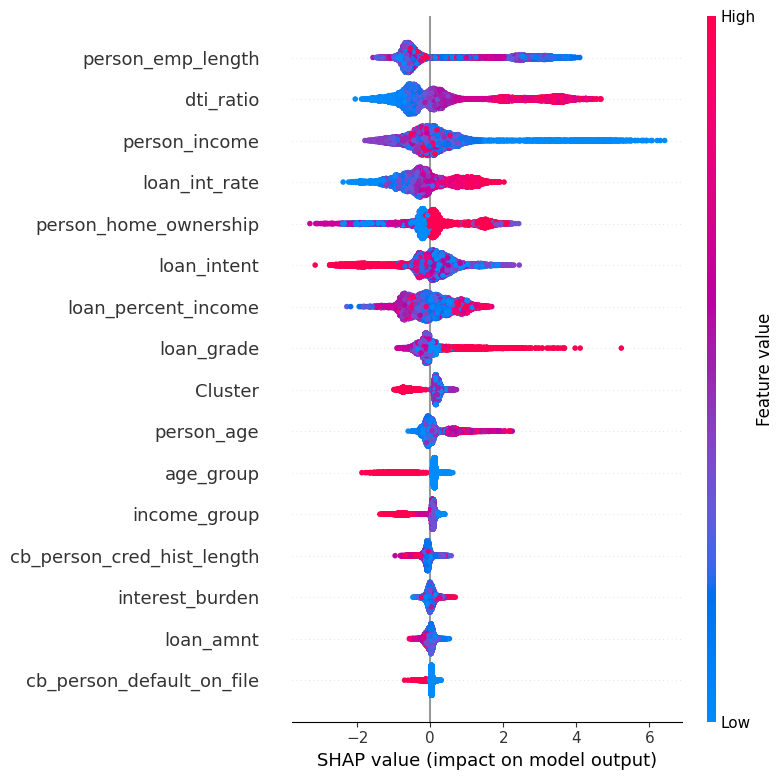

In [15]:
shap.summary_plot(
    shap_values,
    X_test
)

## **Feature Importance**

In [16]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':best_model.feature_importances_

})

In [17]:
importance.sort_values(
'Importance',
ascending=False
)

,Feature,Importance
15,Cluster,0.224228
11,dti_ratio,0.123687
2,person_home_ownership,0.093809
7,loan_int_rate,0.080446
3,person_emp_length,0.079235
5,loan_grade,0.063975
4,loan_intent,0.060022
8,loan_percent_income,0.055891
1,person_income,0.046588
13,age_group,0.046586


<Axes: xlabel='Importance', ylabel='Feature'>

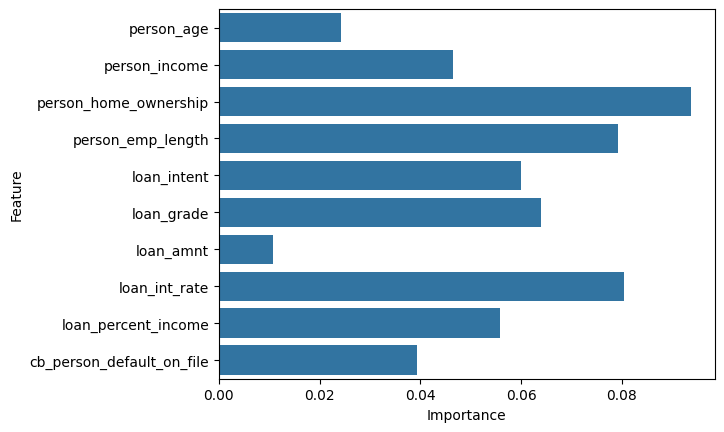

In [18]:
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.barplot(
data=importance.head(10),
x='Importance',
y='Feature'
)

## **Principal Component Analysis (PCA)**

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

In [20]:
pca_df = pd.DataFrame(
principal_components,
columns=['PC1','PC2']
)

<Axes: xlabel='PC1', ylabel='PC2'>

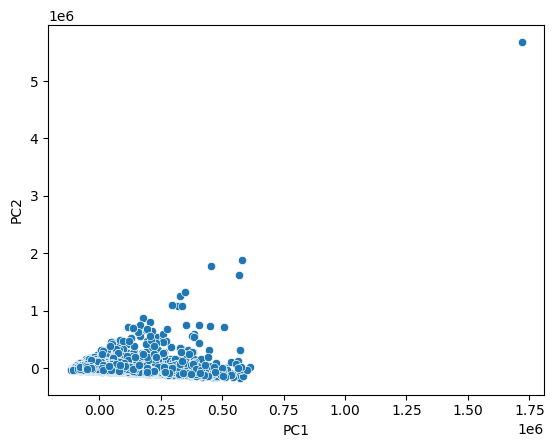

In [21]:
sns.scatterplot(
data=pca_df,
x='PC1',
y='PC2'
)

## **Association Rule Mining**

In [22]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [23]:
df['high_interest'] = (
df['loan_int_rate']>15
)

df['low_income'] = (
df['person_income']<50000
)

df['defaulted'] = (
df['loan_status']==1
)

In [24]:
frequent_itemsets = apriori(
df[['high_interest',
'low_income',
'defaulted']],
min_support=0.05,
use_colnames=True
)

In [25]:
rules = association_rules(
frequent_itemsets,
metric='confidence',
min_threshold=0.5
)

## **Save Final Model**

In [26]:
import joblib

joblib.dump(
best_model,
'final_xgboost_model.pkl'
)

['final_xgboost_model.pkl']

## **Create Power BI Dataset**

In [27]:
final_output = X_test.copy()

final_output['Actual_Default'] = y_test

final_output['Default_Probability'] = default_probability

final_output['Risk_Level'] = risk

In [28]:
home_map = {
    0: 'MORTGAGE',
    1: 'OTHER',
    2: 'OWN',
    3: 'RENT'
}

final_output['Home Ownership'] = final_output['person_home_ownership'].map(home_map)

In [29]:
intent_map = {
    0: 'DEBTCONSOLIDATION',
    1: 'EDUCATION',
    2: 'HOMEIMPROVEMENT',
    3: 'MEDICAL',
    4: 'PERSONAL',
    5: 'VENTURE'
}

final_output['Loan Purpose'] = final_output['loan_intent'].map(intent_map)

In [30]:
grade_map = {
    0: 'A',
    1: 'B',
    2: 'C',
    3: 'D',
    4: 'E',
    5: 'F',
    6: 'G'
}

final_output['Loan Grade'] = final_output['loan_grade'].map(grade_map)

In [31]:
default_map = {
    0: 'N',
    1: 'Y'
}

final_output['Default History'] = final_output['cb_person_default_on_file'].map(default_map)

In [32]:
status_map = {
    0: 'No Default',
    1: 'Default'
}

final_output['Actual Default Status'] = final_output['Actual_Default'].map(status_map)

In [33]:
cluster_mapping = {
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
}

final_output['Cluster_Name'] = final_output['Cluster'].map(cluster_mapping)

In [34]:
final_output.groupby('income_group')['person_income'].agg(['min', 'max'])
final_output.groupby('age_group')['person_age'].agg(['min', 'max'])

,min,max
age_group,,
0,21,39
1,31,48
2,41,56
3,51,63
4,61,78
5,20,123


In [35]:
income_map = {
    0: 'Low Income',
    1: 'Middle Income',
    2: 'Upper Middle Income',
    3: 'High Income'
}

age_map = {
    0: '20-25',
    1: '25-30',
    2: '30-35',
    3: '35-40',
    4: '40-45',
    5: '50+'
}

final_output['Income Group'] = final_output['income_group'].map(income_map)
final_output['Age Group'] = final_output['age_group'].map(age_map)

In [36]:
final_output = final_output.drop(columns=[
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file',
    'Actual_Default'
])

final_output = final_output.drop(columns=[
    'age_group',
    'income_group'
])

In [37]:
final_output.to_csv('data/final_output_human_readable.csv', index=False)

In [38]:
final_output.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,dti_ratio,interest_burden,Cluster,Default_Probability,Risk_Level,Home Ownership,Loan Purpose,Loan Grade,Default History,Actual Default Status,Cluster_Name,Income Group,Age Group
43929,23,29000,4.0,10000,18.62,0.34,3,0.344828,186200.0,0,0.987554,High Risk,OWN,HOMEIMPROVEMENT,F,N,Default,Low Risk,Middle Income,20-25
6651,26,50000,10.0,6000,10.99,0.12,3,0.120000,65940.0,1,0.101133,Low Risk,MORTGAGE,HOMEIMPROVEMENT,B,N,No Default,Medium Risk,Upper Middle Income,20-25
25055,30,34046,2.0,12000,14.96,0.35,6,0.352464,179520.0,0,0.999292,High Risk,RENT,MEDICAL,D,Y,Default,Low Risk,Middle Income,20-25
22707,30,58239,3.0,10500,6.62,0.18,5,0.180292,69510.0,2,0.001857,Low Risk,MORTGAGE,VENTURE,A,N,No Default,High Risk,Low Income,20-25
20807,28,44447,8.0,6000,12.72,0.13,7,0.134992,76320.0,1,0.395709,Medium Risk,MORTGAGE,EDUCATION,C,Y,No Default,Medium Risk,Upper Middle Income,20-25


In [39]:
import os

print(os.path.abspath('data/final_output.csv'))

C:\Users\shrut\data\final_output.csv


In [43]:
import shap
import numpy as np
import pandas as pd

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Compute mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)

# Create DataFrame
shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': shap_importance
})

# Sort descending
shap_df = shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Save to CSV
shap_df.to_csv(
    'shap_feature_importance.csv',
    index=False
)

# Display top features
print(shap_df.head(10))

                  Feature  SHAP_Importance
3       person_emp_length         1.144773
11              dti_ratio         1.025290
1           person_income         0.664550
7           loan_int_rate         0.617619
2   person_home_ownership         0.578614
4             loan_intent         0.538023
8     loan_percent_income         0.486575
5              loan_grade         0.355482
15                Cluster         0.292822
0              person_age         0.268902


In [41]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Predict values
y_pred = best_model.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame
cm_df = pd.DataFrame({
    'Actual': ['No Default',
               'No Default',
               'Default',
               'Default'],

    'Predicted': ['No Default',
                  'Default',
                  'No Default',
                  'Default'],

    'Count': [cm[0,0],
              cm[0,1],
              cm[1,0],
              cm[1,1]]
})

# Save to CSV
cm_df.to_csv(
    'confusion_matrix.csv',
    index=False
)

# Display
print(cm_df)

       Actual   Predicted  Count
0  No Default  No Default   4962
1  No Default     Default     89
2     Default  No Default    471
3     Default     Default   4609


In [1]:
import os
os.getcwd()

'C:\\Users\\shrut'